# *Lepidonotopodium piscesae* — Median Abundance Analysis

<span style="font-family: 'Courier New', monospace;">

*AI-generated draft (Claude, Anthropic) — for review. All parameters and figures are derived from version-controlled scripts and data.*

This notebook implements the median-per-video abundance method. Every frame across a configurable 15-minute Scene 1 window is sampled. The **median worm count per frame within each video** becomes the abundance proxy for that recording. Stringing those medians together produces a time series of abundance across the full month.

**Why median instead of mean?**
The median is resistant to outliers. Frames where the camera briefly shifts, or where worms cluster unusually, will not skew the estimate the way they would with a mean. The median represents the most *typical* frame in that video.

**Workflow:**
1. **Setup** — configure paths, window boundaries, and extraction interval
2. **Find videos** — scan the archive for videos in your date range
3. **Extract frames** — sample frames across the full 15-minute window
4. **Run YOLO** — detect scale worms in every extracted frame
5. **Compute medians** — summarize each video as a single abundance value
6. **Abundance charts** — visualize the monthly trend
7. **Load manual VIAME annotations** — parse expert-annotated CSVs
8. **Manual vs AI comparison** — compare distributions within the Scene 1 window only
9. **Summary statistics** — key numbers for AGU

</span>

## 1. Setup

<span style="font-family: 'Courier New', monospace;">

Run this cell first every time you open the notebook. All key parameters are defined here — adjust `EXTRACT_INTERVAL_SEC` to trade processing speed against temporal resolution. A value of 10 (one frame every 10 seconds) gives 90 frames per video and is a good starting point. Reducing it to 5 doubles the frame count and processing time; increasing it to 30 gives 30 frames per video and runs much faster.

Check the printed output to confirm all paths exist before proceeding.

</span>

In [1]:
import re
import subprocess
import datetime as dt
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e9c46a',
    'xtick.color':      '#e9c46a',
    'ytick.color':      '#e9c46a',
    'text.color':       '#e9c46a',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

TEAL   = '#2ec4b6'
ORANGE = '#e76f51'
GOLD   = '#e9c46a'
BLUE   = '#457b9d'

# ── Paths ─────────────────────────────────────────────────────────────
MODEL_PATH = Path("/home/jovyan/scaleworm-student-lab/mushroom.pt")
VIDEO_ROOT = Path("/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/")
ANNOT_DIR  = Path("/home/jovyan/scaleworm_starter/baseline/annotations_scene1")
WORK_DIR   = Path("./median_abundance_session")
FRAMES_DIR = WORK_DIR / "frames"
EXPORT_DIR = WORK_DIR / "export"

for d in [WORK_DIR, FRAMES_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── 15-minute window parameters ───────────────────────────────────────
# Scene 1 starts at 305s. The 15-minute window runs 305–1205s.
# Adjust EXTRACT_INTERVAL_SEC to control frame density:
#   10s interval → 90 frames/video  (recommended starting point)
#    5s interval → 180 frames/video (higher resolution, slower)
#   30s interval → 30 frames/video  (faster, lower resolution)

WINDOW_START_SEC      = 305    # start of 15-minute window (seconds into video)
WINDOW_END_SEC        = 1205   # end of 15-minute window   (seconds into video)
EXTRACT_INTERVAL_SEC  = 10     # ← ADJUST THIS: one frame every N seconds

# Scene 1 boundaries — used for the manual vs AI comparison only
SCENE1_START_SEC      = 305    # Scene 1 start (same as window start)
SCENE1_END_SEC        = 318    # Scene 1 end (~13 seconds, matching VIAME CSVs)

# Detection parameters
CONF_THRESHOLD = 0.3
MAX_BOX_SIZE   = 300
FRAME_W        = 1920
FRAME_H        = 1080

# Standard 3-hour cadence times (UTC)
STANDARD_TIMES = {
    "T001500", "T031500", "T061500", "T091500",
    "T121500", "T151500", "T181500", "T211500",
}

window_duration = WINDOW_END_SEC - WINDOW_START_SEC
frames_per_vid  = window_duration // EXTRACT_INTERVAL_SEC

print(f"Model       : {MODEL_PATH}  |  exists: {MODEL_PATH.exists()}")
print(f"Video root  : {VIDEO_ROOT}  |  exists: {VIDEO_ROOT.exists()}")
print(f"Annotations : {ANNOT_DIR}  |  exists: {ANNOT_DIR.exists()}")
print(f"Work dir    : {WORK_DIR.resolve()}")
print()
print(f"Window      : {WINDOW_START_SEC}s → {WINDOW_END_SEC}s  ({window_duration/60:.0f} minutes)")
print(f"Interval    : every {EXTRACT_INTERVAL_SEC}s  →  ~{frames_per_vid} frames per video")
print(f"Scene 1     : {SCENE1_START_SEC}s → {SCENE1_END_SEC}s  (used for manual vs AI comparison)")

Model       : /home/jovyan/scaleworm-student-lab/mushroom.pt  |  exists: True
Video root  : /home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301  |  exists: True
Annotations : /home/jovyan/scaleworm_starter/baseline/annotations_scene1  |  exists: True
Work dir    : /home/jovyan/scaleworm-student-lab/notebooks/median_abundance_session

Window      : 305s → 1205s  (15 minutes)
Interval    : every 10s  →  ~90 frames per video
Scene 1     : 305s → 318s  (used for manual vs AI comparison)


## 2. Select Date Range and Find Videos

<span style="font-family: 'Courier New', monospace;">

Set your start and end dates below. The cell scans the video archive and lists all standard-cadence CAMHD videos in that range. CAMHD records at 8 fixed times per day (every 3 hours UTC), so a full month returns approximately 240 videos. If fewer are listed, some recordings may be missing from the archive.

**Expected output:** Total video count and a list of video filenames.

</span>

In [2]:
# ════════════════════════════════════════════════════════════════════
# ▼▼▼  SET YOUR DATE RANGE HERE  ▼▼▼
# ════════════════════════════════════════════════════════════════════

START_DATE = "2024-10-01"
END_DATE   = "2024-10-31"

# ════════════════════════════════════════════════════════════════════

d_start = dt.date.fromisoformat(START_DATE)
d_end   = dt.date.fromisoformat(END_DATE)

videos = []
for mp4 in sorted(VIDEO_ROOT.rglob("CAMHDA301-*.mp4")):
    m = re.search(r"CAMHDA301-(\d{4})(\d{2})(\d{2})T(\d{6})", mp4.name)
    if not m:
        continue
    file_date = dt.date(int(m.group(1)), int(m.group(2)), int(m.group(3)))
    if file_date < d_start or file_date > d_end:
        continue
    if f"T{m.group(4)}" not in STANDARD_TIMES:
        continue
    videos.append(mp4)

videos = sorted(videos)
print(f"Found {len(videos)} videos between {START_DATE} and {END_DATE}")
print(f"Estimated frames to process: {len(videos) * frames_per_vid:,}")
print()
for v in videos[:10]:
    print(f"  {v.name}")
if len(videos) > 10:
    print(f"  ... and {len(videos)-10} more")

Found 247 videos between 2024-10-01 and 2024-10-31
Estimated frames to process: 22,230

  CAMHDA301-20241001T031500.mp4
  CAMHDA301-20241001T061500.mp4
  CAMHDA301-20241001T091500.mp4
  CAMHDA301-20241001T121500.mp4
  CAMHDA301-20241001T151500.mp4
  CAMHDA301-20241001T181500.mp4
  CAMHDA301-20241001T211500.mp4
  CAMHDA301-20241002T001500.mp4
  CAMHDA301-20241002T031500.mp4
  CAMHDA301-20241002T061500.mp4
  ... and 237 more


## 3. Extract Frames Across the 15-Minute Window

<span style="font-family: 'Courier New', monospace;">

Instead of extracting a continuous sequence of frames with ffmpeg's `-vf fps` filter, this cell extracts one frame at each fixed time offset within the 15-minute window. This gives precise control over which seconds are sampled and makes it straightforward to later filter frames by whether they fall within the Scene 1 window.

Each frame is named with its exact offset in seconds (e.g. `offset_0305.png`, `offset_0315.png`) so the timestamp is always recoverable from the filename. Frames that already exist are skipped — this cell is safe to rerun.

**Expected output:** A progress list per video. Total frames should be approximately `number of videos × frames per video`.

</span>

In [6]:
# Build the list of offsets to extract for every video
OFFSETS = list(range(WINDOW_START_SEC, WINDOW_END_SEC, EXTRACT_INTERVAL_SEC))
print(f"Offsets to extract per video: {len(OFFSETS)}")
print(f"  First: {OFFSETS[0]}s  |  Last: {OFFSETS[-1]}s")
print(f"  Scene 1 offsets (for comparison): "
      f"{[o for o in OFFSETS if SCENE1_START_SEC <= o <= SCENE1_END_SEC]}")
print()


def extract_frame_at_offset(video_path, offset_sec, out_path):
    """Extract one frame at a specific second offset using ffmpeg."""
    if out_path.exists():
        return True
    cmd = [
        "ffmpeg", "-y",
        "-ss", str(offset_sec),
        "-i", str(video_path),
        "-frames:v", "1",
        "-q:v", "2",
        str(out_path),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=60)
    return result.returncode == 0 and out_path.exists()


video_frame_dirs = {}
total_extracted  = 0

for i, vpath in enumerate(videos):
    vid_name  = vpath.stem
    frame_dir = FRAMES_DIR / vid_name
    frame_dir.mkdir(parents=True, exist_ok=True)
    video_frame_dirs[vid_name] = frame_dir

    n_extracted = 0
    for offset in OFFSETS:
        out_path = frame_dir / f"offset_{offset:04d}.png"
        if extract_frame_at_offset(vpath, offset, out_path):
            n_extracted += 1

    total_extracted += n_extracted
    print(f"  [{i+1}/{len(videos)}] {vid_name}: {n_extracted}/{len(OFFSETS)} frames")

print(f"\nTotal frames extracted: {total_extracted:,}")

Offsets to extract per video: 90
  First: 305s  |  Last: 1195s
  Scene 1 offsets (for comparison): [305, 315]

  [1/247] CAMHDA301-20241001T031500: 60/90 frames
  [2/247] CAMHDA301-20241001T061500: 60/90 frames
  [3/247] CAMHDA301-20241001T091500: 60/90 frames
  [4/247] CAMHDA301-20241001T121500: 60/90 frames
  [5/247] CAMHDA301-20241001T151500: 60/90 frames
  [6/247] CAMHDA301-20241001T181500: 60/90 frames
  [7/247] CAMHDA301-20241001T211500: 60/90 frames
  [8/247] CAMHDA301-20241002T001500: 60/90 frames
  [9/247] CAMHDA301-20241002T031500: 60/90 frames
  [10/247] CAMHDA301-20241002T061500: 60/90 frames
  [11/247] CAMHDA301-20241002T091500: 60/90 frames
  [12/247] CAMHDA301-20241002T121500: 60/90 frames
  [13/247] CAMHDA301-20241002T151500: 60/90 frames
  [14/247] CAMHDA301-20241002T181500: 60/90 frames
  [15/247] CAMHDA301-20241002T211500: 60/90 frames
  [16/247] CAMHDA301-20241003T001500: 60/90 frames
  [17/247] CAMHDA301-20241003T031500: 60/90 frames
  [18/247] CAMHDA301-20241003T0

## 4. Run YOLO on All Extracted Frames

<span style="font-family: 'Courier New', monospace;">

The Mushroom Model is run on every extracted frame. For each frame, the number of scale worm detections above the confidence threshold is recorded. Each row in the resulting DataFrame represents one frame, storing the video it came from, its offset in seconds, whether it falls within the Scene 1 window, and the detection count.

The Scene 1 flag (`in_scene1`) is set to `True` for frames between `SCENE1_START_SEC` and `SCENE1_END_SEC`. This is used later to filter results for the manual vs AI comparison.

**This cell may take a while** depending on the number of videos and your chosen interval. Progress is printed per video.

</span>

In [7]:
!pip install ultralytics -q

In [8]:
from ultralytics import YOLO

model = YOLO(str(MODEL_PATH))
print(f"Loaded: {MODEL_PATH.name}\n")

FNAME_REGEX  = re.compile(r"(\d{8})T(\d{6})")
OFFSET_REGEX = re.compile(r"offset_(\d+)\.png")
frame_records = []

for vid_name, frame_dir in sorted(video_frame_dirs.items()):
    m = FNAME_REGEX.search(vid_name)
    if not m:
        continue
    vid_date = pd.to_datetime(m.group(1), format='%Y%m%d').date()
    vid_time = m.group(2)
    vid_dt   = datetime.strptime(f"{m.group(1)}{m.group(2)}", "%Y%m%d%H%M%S")

    frame_paths = sorted(frame_dir.glob("offset_*.png"))
    if not frame_paths:
        continue

    results = model.predict(
        source=[str(f) for f in frame_paths],
        conf=CONF_THRESHOLD,
        verbose=False,
        stream=True,
    )

    frame_counts = []
    for frame_path, result in zip(frame_paths, results):
        # Parse the offset from the filename
        om = OFFSET_REGEX.search(frame_path.name)
        offset_sec = int(om.group(1)) if om else -1

        # Count valid detections
        count = 0
        if result.boxes is not None and len(result.boxes) > 0:
            for box in result.boxes.xyxy.cpu().numpy():
                x1, y1, x2, y2 = box
                if (x2-x1) <= MAX_BOX_SIZE and (y2-y1) <= MAX_BOX_SIZE:
                    count += 1

        in_scene1 = SCENE1_START_SEC <= offset_sec <= SCENE1_END_SEC

        frame_records.append({
            'video':      vid_name,
            'datetime':   vid_dt,
            'date':       vid_date,
            'time':       vid_time,
            'offset_sec': offset_sec,
            'in_scene1':  in_scene1,
            'det_count':  count,
        })
        frame_counts.append(count)

    vid_median = np.median(frame_counts) if frame_counts else 0
    print(f"  {vid_name}: {len(frame_paths)} frames | "
          f"min={min(frame_counts)} max={max(frame_counts)} "
          f"median={vid_median:.1f}")

frames_df = pd.DataFrame(frame_records)
frames_df['date'] = pd.to_datetime(frames_df['date'])

print(f"\nTotal frames processed : {len(frames_df):,}")
print(f"Scene 1 frames         : {frames_df['in_scene1'].sum():,}")
print(f"Non-Scene-1 frames     : {(~frames_df['in_scene1']).sum():,}")
frames_df.head()

Loaded: mushroom.pt

  CAMHDA301-20241001T031500: 60 frames | min=0 max=0 median=0.0
  CAMHDA301-20241001T061500: 60 frames | min=0 max=1 median=0.0
  CAMHDA301-20241001T091500: 60 frames | min=0 max=4 median=2.0
  CAMHDA301-20241001T121500: 60 frames | min=0 max=0 median=0.0
  CAMHDA301-20241001T151500: 60 frames | min=0 max=7 median=3.5
  CAMHDA301-20241001T181500: 60 frames | min=3 max=10 median=5.0
  CAMHDA301-20241001T211500: 60 frames | min=2 max=10 median=7.0
  CAMHDA301-20241002T001500: 60 frames | min=0 max=0 median=0.0
  CAMHDA301-20241002T031500: 60 frames | min=0 max=2 median=0.0
  CAMHDA301-20241002T061500: 60 frames | min=0 max=3 median=1.0
  CAMHDA301-20241002T091500: 60 frames | min=0 max=3 median=0.0
  CAMHDA301-20241002T121500: 60 frames | min=0 max=0 median=0.0
  CAMHDA301-20241002T151500: 60 frames | min=0 max=0 median=0.0
  CAMHDA301-20241002T181500: 60 frames | min=0 max=1 median=0.0
  CAMHDA301-20241002T211500: 60 frames | min=0 max=1 median=0.0
  CAMHDA301-20241

,video,datetime,date,time,offset_sec,in_scene1,det_count
0,CAMHDA301-20241001T031500,2024-10-01 03:15:00,2024-10-01,031500,305,True,0
1,CAMHDA301-20241001T031500,2024-10-01 03:15:00,2024-10-01,031500,315,True,0
2,CAMHDA301-20241001T031500,2024-10-01 03:15:00,2024-10-01,031500,325,False,0
3,CAMHDA301-20241001T031500,2024-10-01 03:15:00,2024-10-01,031500,335,False,0
4,CAMHDA301-20241001T031500,2024-10-01 03:15:00,2024-10-01,031500,345,False,0


## 5. Compute Median Abundance Per Video

<span style="font-family: 'Courier New', monospace;">

For each video, the full distribution of per-frame detection counts (across all 15 minutes) is summarized by its **median**. This single value is the abundance proxy for that recording session — it represents the most typical number of scale worms visible in any given sampled frame.

Additional statistics (mean, IQR, min, max) are computed for use in charts and the summary table. A daily median-of-medians is also computed, representing the central tendency across all 8 recordings per day.

**Expected output:** A table with one row per video showing median and supporting statistics.

</span>

In [9]:
# Per-video summary across the full 15-minute window
per_video = (
    frames_df.groupby(['video', 'datetime', 'date', 'time'])['det_count']
    .agg(
        median      = 'median',
        mean        = 'mean',
        std         = 'std',
        min         = 'min',
        max         = 'max',
        q25         = lambda x: x.quantile(0.25),
        q75         = lambda x: x.quantile(0.75),
        frame_count = 'count',
    )
    .reset_index()
    .sort_values('datetime')
)
per_video['iqr'] = per_video['q75'] - per_video['q25']

# Daily median of medians
per_day = (
    per_video.groupby('date')['median']
    .agg(
        daily_median = 'median',
        daily_mean   = 'mean',
        daily_std    = 'std',
        n_videos     = 'count',
    )
    .reset_index()
)
per_day['date'] = pd.to_datetime(per_day['date'])

print(f"Videos summarized : {len(per_video)}")
print(f"Days with data    : {len(per_day)}")
print()
print(per_video[['video','median','mean','std','min','max','iqr','frame_count']].to_string(index=False))

Videos summarized : 247
Days with data    : 31

                    video  median     mean      std  min  max  iqr  frame_count
CAMHDA301-20241001T031500     0.0 0.000000 0.000000    0    0 0.00           60
CAMHDA301-20241001T061500     0.0 0.016667 0.129099    0    1 0.00           60
CAMHDA301-20241001T091500     2.0 1.650000 1.054852    0    4 1.00           60
CAMHDA301-20241001T121500     0.0 0.000000 0.000000    0    0 0.00           60
CAMHDA301-20241001T151500     3.5 3.366667 1.775222    0    7 2.00           60
CAMHDA301-20241001T181500     5.0 5.466667 1.908648    3   10 3.00           60
CAMHDA301-20241001T211500     7.0 6.983333 1.799168    2   10 2.00           60
CAMHDA301-20241002T001500     0.0 0.000000 0.000000    0    0 0.00           60
CAMHDA301-20241002T031500     0.0 0.450000 0.648989    0    2 1.00           60
CAMHDA301-20241002T061500     1.0 1.233333 0.908839    0    3 1.00           60
CAMHDA301-20241002T091500     0.0 0.450000 0.674600    0    3 1.00      

## 6. Abundance Over Time Charts

<span style="font-family: 'Courier New', monospace;">

Three charts are produced:

- **Per-video median with IQR band** — finest time resolution (8 points per day). The shaded band shows the interquartile range of frame counts within each video, giving a sense of within-video variability.
- **Daily median of medians** — each day summarized as the median of its 8 per-video medians, with a 7-day rolling mean to show the broader monthly trend.
- **Detection count heatmap** — shows how per-frame counts are distributed across the 15-minute window over time, revealing whether certain parts of the window consistently show more worms.

All charts are saved to the export directory.

</span>

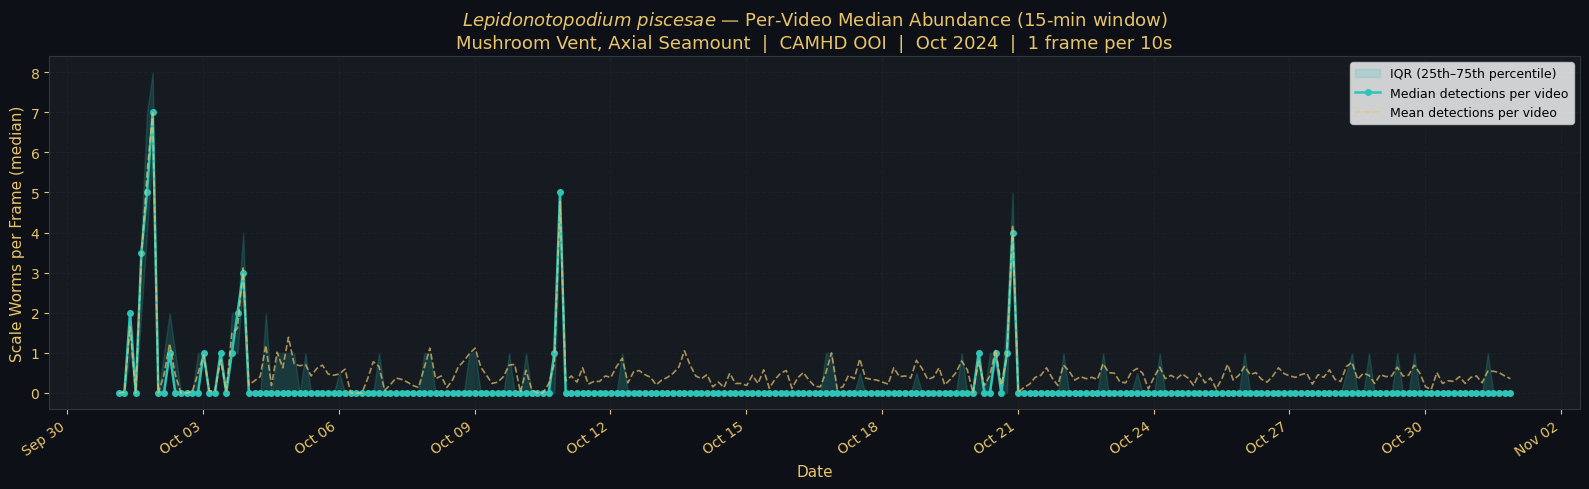

Saved: fig1_per_video_median.png


In [10]:
# ── Chart 1: Per-video median with IQR band ───────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(per_video['datetime'],
                per_video['q25'], per_video['q75'],
                alpha=0.18, color=TEAL,
                label='IQR (25th–75th percentile)')
ax.plot(per_video['datetime'], per_video['median'],
        color=TEAL, linewidth=1.8, marker='o', markersize=4,
        label='Median detections per video')
ax.plot(per_video['datetime'], per_video['mean'],
        color=GOLD, linewidth=1.2, linestyle='--', alpha=0.7,
        label='Mean detections per video')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Scale Worms per Frame (median)')
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Per-Video Median Abundance (15-min window)'
    f'\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024'
    f'  |  1 frame per {EXTRACT_INTERVAL_SEC}s'
)
ax.legend(facecolor='white', labelcolor='black', fontsize=9)
ax.grid(True)
fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig1_per_video_median.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_per_video_median.png')

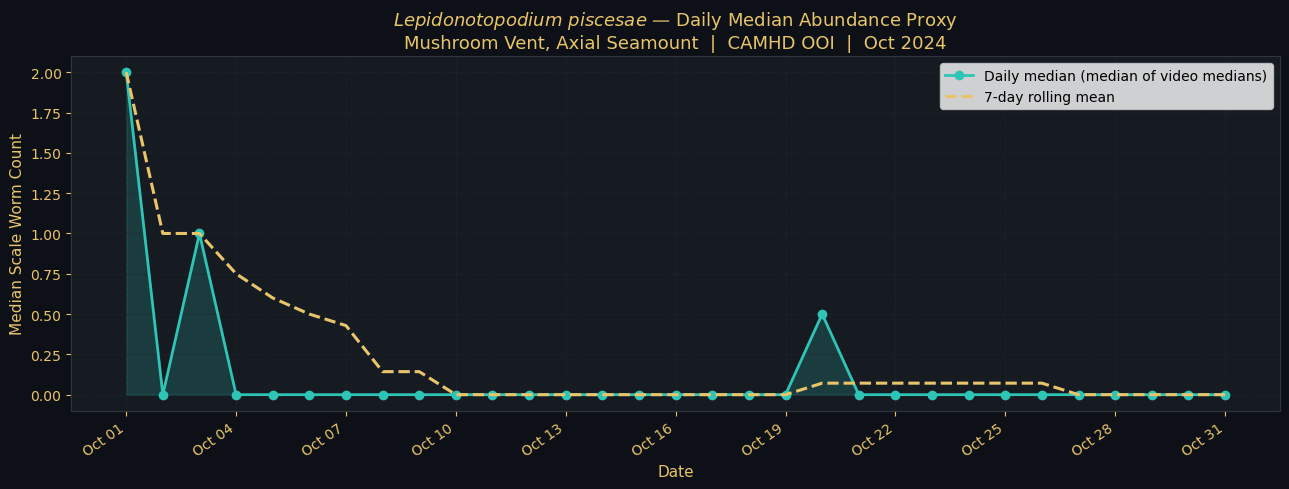

Saved: fig2_daily_median.png


In [11]:
# ── Chart 2: Daily median of medians with rolling mean ───────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(per_day['date'], per_day['daily_median'],
                alpha=0.20, color=TEAL)
ax.plot(per_day['date'], per_day['daily_median'],
        color=TEAL, linewidth=2, marker='o', markersize=6,
        label='Daily median (median of video medians)')

if len(per_day) >= 7:
    rolling = per_day.set_index('date')['daily_median'].rolling('7D').mean()
    ax.plot(rolling.index, rolling.values,
            color=GOLD, linewidth=2.2, linestyle='--',
            label='7-day rolling mean')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Median Scale Worm Count')
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Daily Median Abundance Proxy'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024'
)
ax.legend(facecolor='white', labelcolor='black')
ax.grid(True)
fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig2_daily_median.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_daily_median.png')

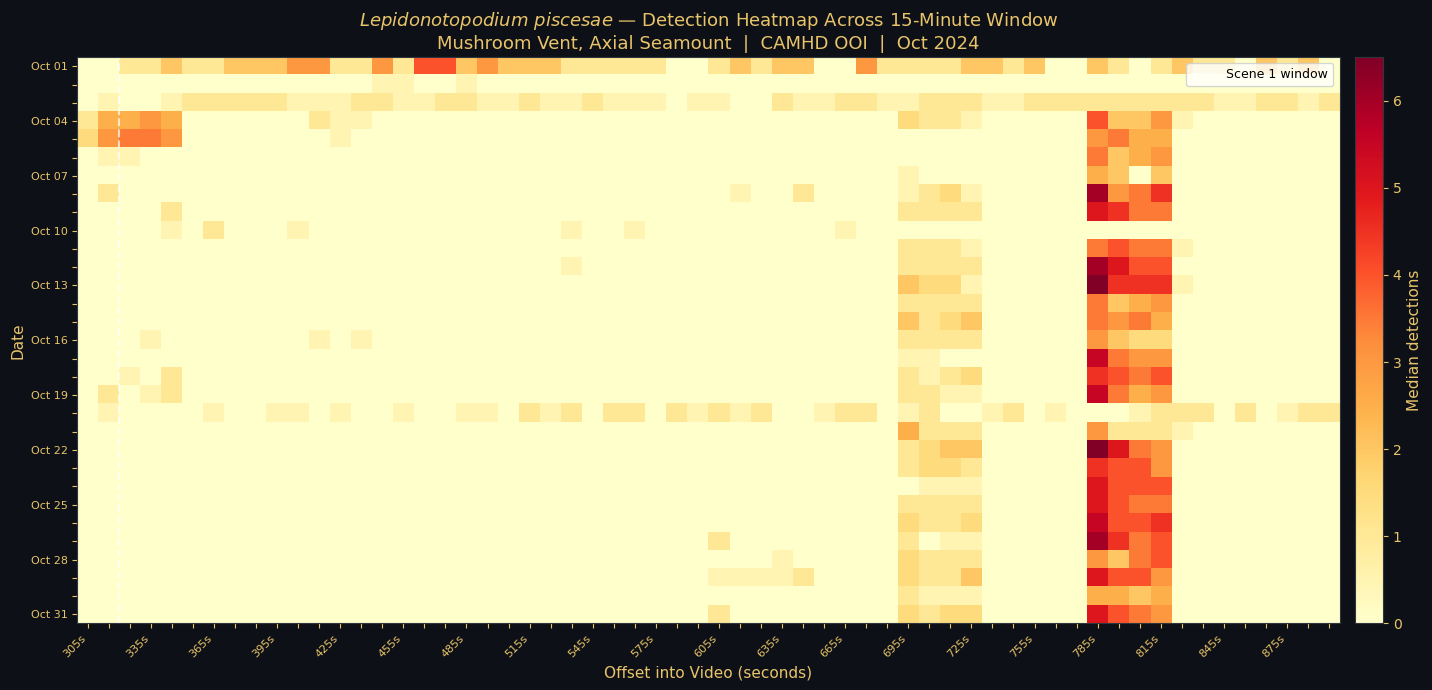

Saved: fig3_heatmap.png


In [12]:
# ── Chart 3: Heatmap — detections by offset and date ─────────────────
# Shows whether certain parts of the 15-minute window consistently
# show more or fewer worms across the month

heatmap_pivot = (
    frames_df.groupby(['date', 'offset_sec'])['det_count']
    .median()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 7))
im = ax.imshow(
    heatmap_pivot.values,
    aspect='auto', cmap='YlOrRd', interpolation='nearest'
)
cbar = fig.colorbar(im, ax=ax, pad=0.01)
cbar.set_label('Median detections', color=GOLD)
cbar.ax.yaxis.set_tick_params(color=GOLD)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=GOLD)

# X axis — offset labels
offsets = list(heatmap_pivot.columns)
ax.set_xticks(range(len(offsets)))
ax.set_xticklabels(
    [f"{o}s" if i % 3 == 0 else '' for i, o in enumerate(offsets)],
    rotation=45, ha='right', fontsize=8
)

# Highlight Scene 1 region
scene1_cols = [i for i, o in enumerate(offsets)
               if SCENE1_START_SEC <= o <= SCENE1_END_SEC]
if scene1_cols:
    ax.axvline(min(scene1_cols) - 0.5, color='white', linewidth=1.5,
               linestyle='--', alpha=0.7)
    ax.axvline(max(scene1_cols) + 0.5, color='white', linewidth=1.5,
               linestyle='--', alpha=0.7, label='Scene 1 window')
    ax.legend(facecolor='white', labelcolor='black', fontsize=9,
              loc='upper right')

# Y axis — date labels
dates = list(heatmap_pivot.index)
ax.set_yticks(range(len(dates)))
ax.set_yticklabels(
    [pd.to_datetime(d).strftime('%b %d') if i % 3 == 0 else ''
     for i, d in enumerate(dates)],
    fontsize=8
)
ax.set_xlabel('Offset into Video (seconds)')
ax.set_ylabel('Date')
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Detection Heatmap Across 15-Minute Window'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024'
)
fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_heatmap.png')

## 7. Load Manual VIAME Annotations

<span style="font-family: 'Courier New', monospace;">

The VIAME CSV files contain expert human annotations of scale worms from March, June, and August 2023 — the data used to train the Mushroom Model. Each row represents one detection in one frame. The CSVs cover approximately 13 seconds of Scene 1 footage per video, recorded at 10fps.

**VIAME column mapping:**
- Column 0 = track/detection ID
- Column 1 = timestamp within video
- Column 2 = frame number
- Columns 3–6 = bounding box (TL_x, TL_y, BR_x, BR_y)
- Column 7 = confidence
- Column 9 = species label

Per-frame worm counts are computed by counting detections per frame number within each CSV.

**Expected output:** Total annotation rows, date range, and a preview of the parsed table.

</span>

In [13]:
COL_NAMES   = [
    'track_id', 'timestamp', 'frame_num',
    'tl_x', 'tl_y', 'br_x', 'br_y',
    'confidence', 'target_length', 'species', 'species_conf'
]
VIAME_REGEX = re.compile(r"CAMHDA301-(\d{8})T(\d{6})")

annot_records = []
csvs = sorted(ANNOT_DIR.glob("*.csv"))
print(f"Loading {len(csvs)} annotation CSVs...\n")

for csv_path in csvs:
    m = VIAME_REGEX.search(csv_path.stem)
    if not m:
        print(f"  WARNING: could not parse date from {csv_path.name} — skipping")
        continue

    vid_date = pd.to_datetime(m.group(1), format='%Y%m%d').date()
    vid_time = m.group(2)

    df = pd.read_csv(csv_path, header=None, skiprows=2,
                     names=COL_NAMES, on_bad_lines='skip')
    df = df[df['species'].astype(str).str.strip() == 'scale_worm'].copy()
    df['date']     = vid_date
    df['time']     = vid_time
    df['csv_file'] = csv_path.name
    annot_records.append(df)
    print(f"  {csv_path.name}: {len(df)} scale_worm detections")

annot_df = pd.concat(annot_records, ignore_index=True)
annot_df['frame_num'] = pd.to_numeric(annot_df['frame_num'], errors='coerce')
annot_df['date']      = pd.to_datetime(annot_df['date'])

# Per-frame count from manual annotations
manual_per_frame = (
    annot_df.groupby(['csv_file', 'date', 'frame_num'])['track_id']
    .count()
    .reset_index()
    .rename(columns={'track_id': 'det_count'})
)

print(f"\nTotal manual detections : {len(annot_df):,}")
print(f"Date range              : {annot_df['date'].min().date()} to {annot_df['date'].max().date()}")
print(f"Unique videos annotated : {annot_df['csv_file'].nunique()}")
print(f"Per-frame count range   : {manual_per_frame['det_count'].min()} to {manual_per_frame['det_count'].max()}")
annot_df.head()

Loading 39 annotation CSVs...

  CAMHDA301-20230305T001500_scene1.csv: 2730 scale_worm detections
  CAMHDA301-20230306T001500_scene1.csv: 895 scale_worm detections
  CAMHDA301-20230312T001500_scene1.csv: 927 scale_worm detections
  CAMHDA301-20230313T001500_scene1.csv: 1133 scale_worm detections
  CAMHDA301-20230316T001500_scene1.csv: 2079 scale_worm detections
  CAMHDA301-20230317T001500_scene1.csv: 1400 scale_worm detections
  CAMHDA301-20230318T001500_scene1.csv: 2060 scale_worm detections
  CAMHDA301-20230319T001500_scene1.csv: 1700 scale_worm detections
  CAMHDA301-20230322T001500_scene1.csv: 1352 scale_worm detections
  CAMHDA301-20230323T001500_scene1.csv: 1600 scale_worm detections
  CAMHDA301-20230325T001500_scene1.csv: 742 scale_worm detections
  CAMHDA301-20230326T001500_scene1.csv: 1060 scale_worm detections
  CAMHDA301-20230328T001500_scene1.csv: 714 scale_worm detections
  CAMHDA301-20230329T001500_scene1.csv: 535 scale_worm detections
  CAMHDA301-20230330T001500_scene1.c

,track_id,timestamp,frame_num,tl_x,tl_y,br_x,br_y,confidence,target_length,species,species_conf,date,time,csv_file
0,0,00:00:00.000000,0,1080,330,1166,384,1.0,-1,scale_worm,1.0,2023-03-05,001500,CAMHDA301-20230305T001500_scene1.csv
1,0,00:00:00.100000,1,1080,335,1166,384,1.0,-1,scale_worm,1.0,2023-03-05,001500,CAMHDA301-20230305T001500_scene1.csv
2,0,00:00:00.200000,2,1080,335,1166,384,1.0,-1,scale_worm,1.0,2023-03-05,001500,CAMHDA301-20230305T001500_scene1.csv
3,0,00:00:00.300000,3,1080,335,1166,384,1.0,-1,scale_worm,1.0,2023-03-05,001500,CAMHDA301-20230305T001500_scene1.csv
4,0,00:00:00.400000,4,1080,335,1166,384,1.0,-1,scale_worm,1.0,2023-03-05,001500,CAMHDA301-20230305T001500_scene1.csv


## 8. Manual vs AI Comparison — Scene 1 Window

<span style="font-family: 'Courier New', monospace;">

Because the VIAME annotations cover only ~13 seconds of Scene 1 footage per video, the YOLO detections are filtered to the same Scene 1 window (`SCENE1_START_SEC` to `SCENE1_END_SEC`) for this comparison. This ensures both methods are evaluated on the same portion of the video.

Since the two datasets cover different years (2023 manual, 2024 YOLO), a direct frame-by-frame match is not possible. The comparison is **distributional** — asking whether the model produces ecologically plausible per-frame counts relative to what a human expert observed at the same vent location.

A **Mann-Whitney U test** is used to assess whether the two distributions are significantly different. This non-parametric test is appropriate because per-frame detection counts are not expected to be normally distributed.

**Expected output:** A four-panel comparison chart saved to the export directory.

</span>

YOLO Scene 1 frames   : 494  (offsets 305–318s)
Manual annotated frames: 4,101  (~13s at 10fps per video)
YOLO Scene 1 median   : 0.00
Manual median         : 11.00


/tmp/ipykernel_28767/2095309734.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


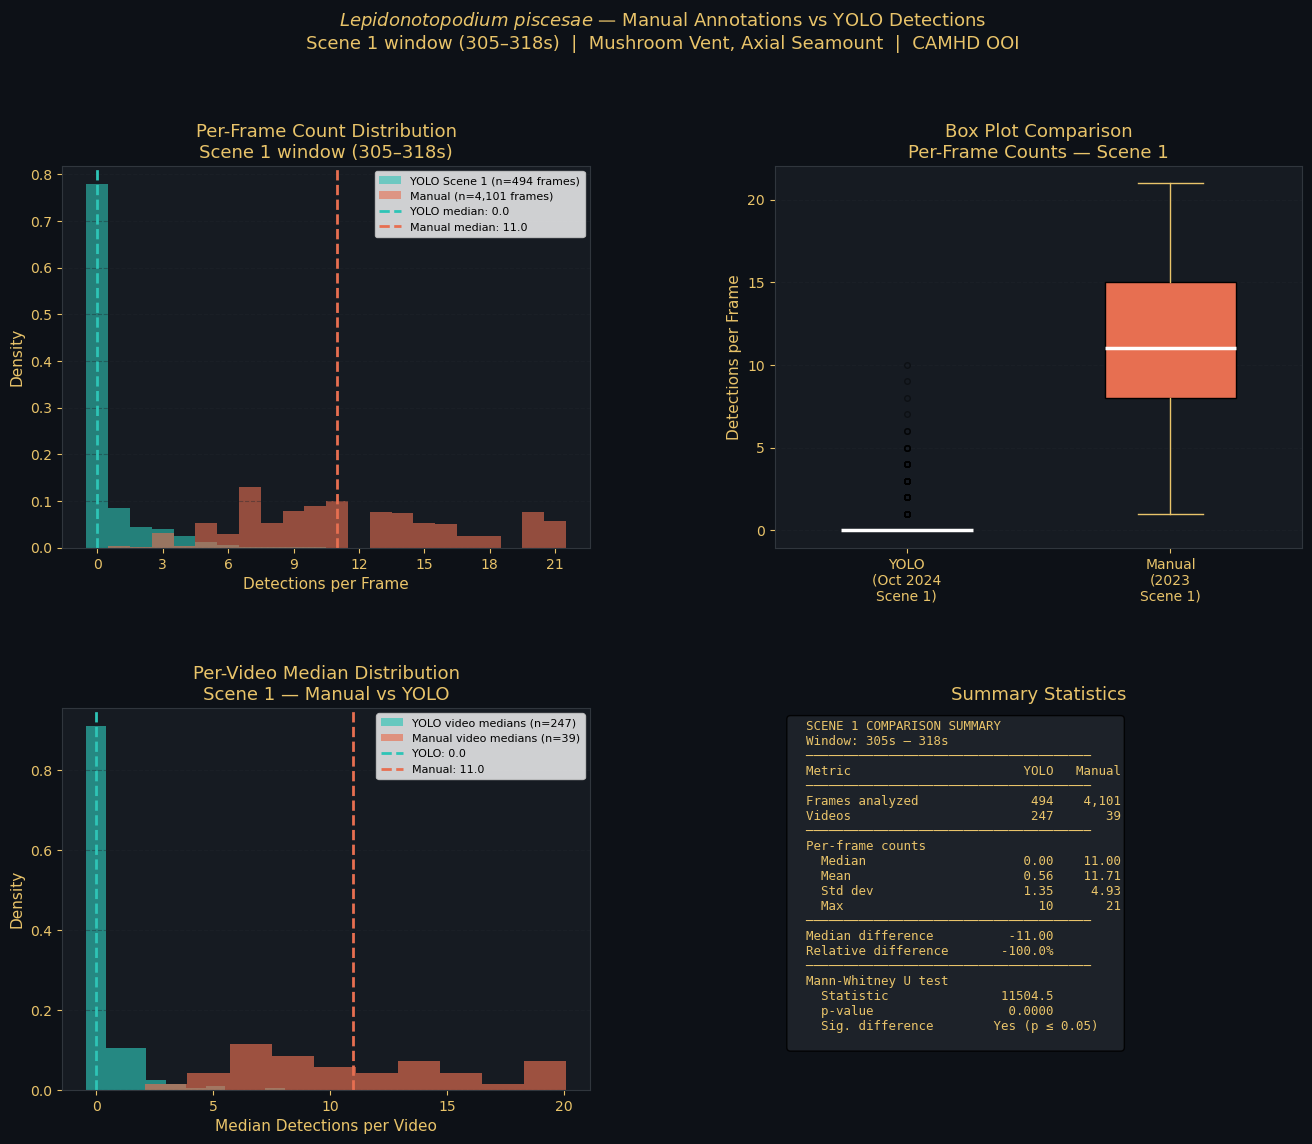

Saved: fig4_manual_vs_ai.png


In [14]:
# Filter YOLO to Scene 1 window only
yolo_scene1 = frames_df[frames_df['in_scene1']].copy()
yolo_counts   = yolo_scene1['det_count'].values
manual_counts = manual_per_frame['det_count'].values

print(f"YOLO Scene 1 frames   : {len(yolo_counts):,}  "
      f"(offsets {SCENE1_START_SEC}–{SCENE1_END_SEC}s)")
print(f"Manual annotated frames: {len(manual_counts):,}  "
      f"(~13s at 10fps per video)")
print(f"YOLO Scene 1 median   : {np.median(yolo_counts):.2f}")
print(f"Manual median         : {np.median(manual_counts):.2f}")

# Per-video medians for Scene 1
yolo_scene1_medians = (
    yolo_scene1.groupby('video')['det_count']
    .median().values
)
manual_per_video = (
    manual_per_frame.groupby('csv_file')['det_count']
    .agg(median='median', mean='mean', std='std',
         min='min', max='max',
         q25=lambda x: x.quantile(0.25),
         q75=lambda x: x.quantile(0.75))
    .reset_index()
)
manual_medians = manual_per_video['median'].values

# Mann-Whitney U test
mw_stat, mw_p = stats.mannwhitneyu(
    yolo_counts, manual_counts, alternative='two-sided'
)
sig_str = 'Yes (p ≤ 0.05)' if mw_p <= 0.05 else 'No (p > 0.05)'

# ── Four-panel comparison chart ───────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# Panel 1 — Overlaid histograms (per-frame counts)
ax1 = fig.add_subplot(gs[0, 0])
max_count = max(int(yolo_counts.max()), int(manual_counts.max()))
bins = range(0, max_count + 2)
ax1.hist(yolo_counts,   bins=bins, color=TEAL,   alpha=0.6, density=True,
         align='left', label=f'YOLO Scene 1 (n={len(yolo_counts):,} frames)')
ax1.hist(manual_counts, bins=bins, color=ORANGE, alpha=0.6, density=True,
         align='left', label=f'Manual (n={len(manual_counts):,} frames)')
ax1.axvline(np.median(yolo_counts),   color=TEAL,   linewidth=2,
            linestyle='--', label=f'YOLO median: {np.median(yolo_counts):.1f}')
ax1.axvline(np.median(manual_counts), color=ORANGE, linewidth=2,
            linestyle='--', label=f'Manual median: {np.median(manual_counts):.1f}')
ax1.set_xlabel('Detections per Frame')
ax1.set_ylabel('Density')
ax1.set_title(
    f'Per-Frame Count Distribution\nScene 1 window ({SCENE1_START_SEC}–{SCENE1_END_SEC}s)'
)
ax1.legend(facecolor='white', labelcolor='black', fontsize=8)
ax1.grid(True, axis='y', alpha=0.4)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel 2 — Box plots
ax2 = fig.add_subplot(gs[0, 1])
bp  = ax2.boxplot(
    [yolo_counts, manual_counts],
    patch_artist=True, vert=True, widths=0.5,
    medianprops=dict(linewidth=2.5, color='white'),
    whiskerprops=dict(color=GOLD),
    capprops=dict(color=GOLD),
    flierprops=dict(marker='o', markersize=4, alpha=0.4)
)
bp['boxes'][0].set_facecolor(TEAL)
bp['boxes'][1].set_facecolor(ORANGE)
bp['fliers'][0].set_color(TEAL)
bp['fliers'][1].set_color(ORANGE)
ax2.set_xticks([1, 2])
ax2.set_xticklabels([
    f'YOLO\n(Oct 2024\nScene 1)',
    f'Manual\n(2023\nScene 1)'
])
ax2.set_ylabel('Detections per Frame')
ax2.set_title('Box Plot Comparison\nPer-Frame Counts — Scene 1')
ax2.grid(True, axis='y', alpha=0.4)

# Panel 3 — Per-video median distributions
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(yolo_scene1_medians, bins=10, color=TEAL,   alpha=0.65, density=True,
         label=f'YOLO video medians (n={len(yolo_scene1_medians)})',   align='left')
ax3.hist(manual_medians,      bins=10, color=ORANGE, alpha=0.65, density=True,
         label=f'Manual video medians (n={len(manual_medians)})', align='left')
ax3.axvline(np.median(yolo_scene1_medians), color=TEAL,   linewidth=2,
            linestyle='--', label=f'YOLO: {np.median(yolo_scene1_medians):.1f}')
ax3.axvline(np.median(manual_medians),      color=ORANGE, linewidth=2,
            linestyle='--', label=f'Manual: {np.median(manual_medians):.1f}')
ax3.set_xlabel('Median Detections per Video')
ax3.set_ylabel('Density')
ax3.set_title('Per-Video Median Distribution\nScene 1 — Manual vs YOLO')
ax3.legend(facecolor='white', labelcolor='black', fontsize=8)
ax3.grid(True, axis='y', alpha=0.4)

# Panel 4 — Summary statistics table
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

diff    = np.median(yolo_counts) - np.median(manual_counts)
pct_diff= (diff / np.median(manual_counts) * 100
           if np.median(manual_counts) != 0 else float('nan'))

table_text = (
    f"  SCENE 1 COMPARISON SUMMARY\n"
    f"  Window: {SCENE1_START_SEC}s – {SCENE1_END_SEC}s\n"
    f"  {'─'*38}\n"
    f"  {'Metric':<24} {'YOLO':>8} {'Manual':>8}\n"
    f"  {'─'*38}\n"
    f"  {'Frames analyzed':<24} {len(yolo_counts):>8,} {len(manual_counts):>8,}\n"
    f"  {'Videos':<24} {len(yolo_scene1_medians):>8} {len(manual_medians):>8}\n"
    f"  {'─'*38}\n"
    f"  Per-frame counts\n"
    f"  {'  Median':<24} {np.median(yolo_counts):>8.2f} {np.median(manual_counts):>8.2f}\n"
    f"  {'  Mean':<24} {np.mean(yolo_counts):>8.2f} {np.mean(manual_counts):>8.2f}\n"
    f"  {'  Std dev':<24} {np.std(yolo_counts):>8.2f} {np.std(manual_counts):>8.2f}\n"
    f"  {'  Max':<24} {int(yolo_counts.max()):>8} {int(manual_counts.max()):>8}\n"
    f"  {'─'*38}\n"
    f"  {'Median difference':<24} {diff:>+8.2f}\n"
    f"  {'Relative difference':<24} {pct_diff:>+7.1f}%\n"
    f"  {'─'*38}\n"
    f"  Mann-Whitney U test\n"
    f"  {'  Statistic':<24} {mw_stat:>8.1f}\n"
    f"  {'  p-value':<24} {mw_p:>8.4f}\n"
    f"  {'  Sig. difference':<24} {sig_str}\n"
)
ax4.text(0.03, 0.97, table_text, transform=ax4.transAxes,
         fontsize=9, verticalalignment='top',
         fontfamily='monospace', color=GOLD,
         bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.85))
ax4.set_title('Summary Statistics')

fig.suptitle(
    r'$Lepidonotopodium\ piscesae$ — Manual Annotations vs YOLO Detections'
    f'\nScene 1 window ({SCENE1_START_SEC}–{SCENE1_END_SEC}s)  |  '
    'Mushroom Vent, Axial Seamount  |  CAMHD OOI',
    fontsize=13, y=1.01
)
fig.patch.set_facecolor('#0d1117')
for a in [ax1, ax2, ax3, ax4]:
    a.set_facecolor('#161b22')

fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig4_manual_vs_ai.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_manual_vs_ai.png')

## 9. Summary Statistics

<span style="font-family: 'Courier New', monospace;">

A full printed summary of the analysis. The abundance section covers the full 15-minute window; the comparison section covers the Scene 1 window only. Use these numbers when writing up results for AGU.

</span>

In [15]:
print('=' * 60)
print('  MEDIAN ABUNDANCE ANALYSIS — SUMMARY')
print('=' * 60)
print(f'  Species   : Lepidonotopodium piscesae')
print(f'  Site      : Mushroom Vent, Axial Seamount')
print(f'  Period    : {START_DATE}  →  {END_DATE}')
print(f'  Window    : {WINDOW_START_SEC}s – {WINDOW_END_SEC}s  ({(WINDOW_END_SEC-WINDOW_START_SEC)//60} min)')
print(f'  Interval  : 1 frame per {EXTRACT_INTERVAL_SEC}s  (~{frames_per_vid} frames/video)')
print('-' * 60)
print(f'  YOLO abundance (full 15-minute window)')
print(f'    Videos processed        : {len(per_video)}')
print(f'    Total frames analyzed   : {len(frames_df):,}')
print(f'    Median of video medians : {per_video["median"].median():.2f} worms/frame')
print(f'    Mean of video medians   : {per_video["median"].mean():.2f} worms/frame')
print(f'    Highest video median    : {per_video["median"].max():.1f}')
print(f'    Lowest video median     : {per_video["median"].min():.1f}')
print('-' * 60)
print(f'  Manual vs AI — Scene 1 window ({SCENE1_START_SEC}–{SCENE1_END_SEC}s)')
print(f'    YOLO frames (Scene 1)   : {len(yolo_counts):,}')
print(f'    Manual frames           : {len(manual_counts):,}')
print(f'    YOLO median per frame   : {np.median(yolo_counts):.2f}')
print(f'    Manual median per frame : {np.median(manual_counts):.2f}')
print(f'    Difference              : {diff:+.2f} ({pct_diff:+.1f}%)')
print(f'    Statistically different : {sig_str}')
print('-' * 60)
print(f'  NOTE: Manual annotations cover 2023 (Mar/Jun/Aug).')
print(f'  YOLO covers Oct 2024. Comparison is distributional,')
print(f'  not temporally matched.')
print('=' * 60)

  MEDIAN ABUNDANCE ANALYSIS — SUMMARY
  Species   : Lepidonotopodium piscesae
  Site      : Mushroom Vent, Axial Seamount
  Period    : 2024-10-01  →  2024-10-31
  Window    : 305s – 1205s  (15 min)
  Interval  : 1 frame per 10s  (~90 frames/video)
------------------------------------------------------------
  YOLO abundance (full 15-minute window)
    Videos processed        : 247
    Total frames analyzed   : 14,610
    Median of video medians : 0.00 worms/frame
    Mean of video medians   : 0.16 worms/frame
    Highest video median    : 7.0
    Lowest video median     : 0.0
------------------------------------------------------------
  Manual vs AI — Scene 1 window (305–318s)
    YOLO frames (Scene 1)   : 494
    Manual frames           : 4,101
    YOLO median per frame   : 0.00
    Manual median per frame : 11.00
    Difference              : -11.00 (-100.0%)
    Statistically different : Yes (p ≤ 0.05)
------------------------------------------------------------
  NOTE: Manual ann